In [1]:
import pywt
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
working_dir = os.getcwd()
FOLDER_NAME = os.path.basename(working_dir)
FILE_NAME = 'plot data'

STOCK = 'BTC'
FREQ = '1min'
LEVEL = 2

TRADE_PRICE = 'close'


SEQ_LENGTH = 48
BATCH_SIZE = 8

TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.1
TEST_SPLIT = 1 - (TRAIN_SPLIT+VAL_SPLIT)

In [3]:
os.getcwd()

'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\denoise'

In [4]:
os.chdir('..')
df = pd.read_csv(f'data/{STOCK}USD_2023_2024.csv', index_col='Gmt time')
df.index = pd.to_datetime(df.index, format="%d.%m.%Y %H:%M:%S.%f", errors='coerce')
df = df.rename(columns={'Date':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})

In [5]:
from utils.utils import CreateTimeFrames
df = CreateTimeFrames(df, [FREQ])[FREQ]
df = df.iloc[-4050:,:]

In [6]:
close = df[f'{TRADE_PRICE}'].to_numpy(dtype=np.int32)
print(f'There are {close.size} {TRADE_PRICE} prices.')

There are 4050 close prices.


# V2

In [7]:

import pywt
import numpy as np

# -------------------------------------------------------------------------------------------
# Wavelet denoising
#
# Reference: https://doi.org/10.1002/for.3071
# (the idea of the wavelet denoising and some parameters are taken from this paper)
# -------------------------------------------------------------------------------------------

# Function for padding the data
def pad_data(data, pad_width, mode='edge'):
    return np.pad(data, pad_width, mode=mode)

# Wavelet denoising function with parameterisation for wavelet type and decomposition level
def wavelet_denoising(data, wavelet='db4', level=1):
    # Padding with a width of 100
    padded_data = pad_data(data, pad_width=100, mode='edge')
    # Decompose signal using Wavelet Transform
    coeff = pywt.wavedec(padded_data, wavelet, mode="per", level=level)
    coeff_out = coeff.copy()
    # Estimate the noise level
    sigma = (1 / 0.6745) * np.median(np.abs(coeff[-level] - np.median(coeff[-level])))
    # Calculate the universal threshold
    uthresh = sigma * np.sqrt(2 * np.log(len(padded_data)))
    # uthresh = [sigma * np.sqrt(2 * np.log(len(padded_data))) / (2 ** (i + 1)) for i in range(level)]
    # Apply soft thresholding to detail coefficients
    coeff[1:] = [pywt.threshold(i, value=uthresh, mode='hard') for i in coeff[1:]]
    # coeff[1:] = [pywt.threshold(i, value=thresh, mode='soft') for i, thresh in zip(coeff[1:], uthresh)]
    # Set high-frequency coefficients to zero ]
    coeff[-level] = np.zeros_like(coeff[-level])
    # Reconstruct the denoised signal
    denoised_data = pywt.waverec(coeff, wavelet, mode='per')
    # Remove the padding
    denoised_data = denoised_data[100:-100]  # Adjust this if necessary

    # Handle edge effects
    if len(denoised_data) > len(data):
        denoised_data = denoised_data[:len(data)]
    elif len(denoised_data) < len(data):
        denoised_data = np.pad(denoised_data, (0, len(data) - len(denoised_data)), 'edge')

    return denoised_data, coeff_out, sigma, uthresh, coeff


In [8]:
denoised_data_1, coeff_out_1, sigma_1, uthresh_1, coeff_1 = wavelet_denoising(close, level=1)
denoised_data_2, coeff_out_2, sigma_2, uthresh_2, coeff_2 = wavelet_denoising(close, level=2)
denoised_data_3, coeff_out_3, sigma_3, uthresh_3, coeff_3 = wavelet_denoising(close, level=3)

In [9]:
close

array([68535, 68618, 68577, ..., 69319, 69331, 69343])

In [10]:
close

array([68535, 68618, 68577, ..., 69319, 69331, 69343])

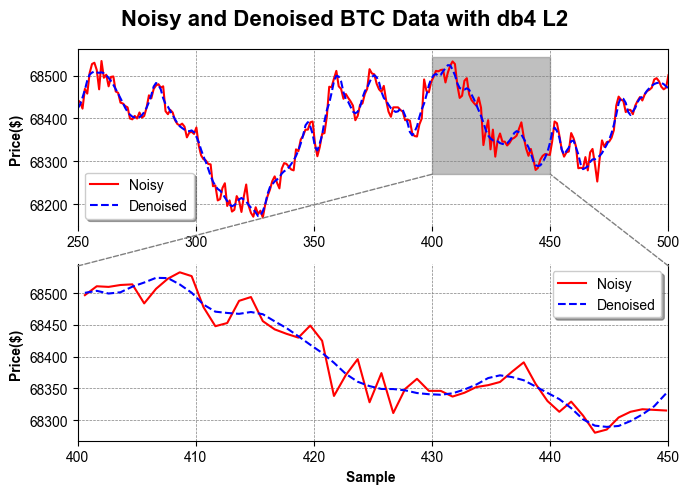

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch, Polygon


plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']


t1 = 250
t2 = 500
t = np.linspace(t1, t2, t2-t1)
signal1 = close[t1:t2]
signal3 = denoised_data_2[t1:t2]

# Define zoom-in region
t_zoom_start, t_zoom_end = 400, 450
mask = (t >= t_zoom_start) & (t <= t_zoom_end)

# Create the figure and axes
fig, axs = plt.subplots(2, 1, figsize=(7, 5))

# Main plot
axs[0].plot(t, signal1, 'r', label=f'Noisy')
# axs[0].plot(t, signal2, 'b--', label=f'Denoised L1')
axs[0].plot(t, signal3, 'b--', label=f'Denoised' )
axs[0].set_xlim(t1,t2)
axs[0].grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
axs[0].set_ylabel('Price($) ', fontsize=10, fontweight='bold')
axs[0].legend(loc='best', fontsize=10, frameon=True, shadow=True, fancybox=True)
axs[0].set_facecolor('white')


axs[0].spines['top'].set_visible(True)
axs[0].spines['right'].set_visible(True)
axs[0].spines['bottom'].set_visible(False)
axs[0].spines['left'].set_visible(True)


fig.suptitle(f'Noisy and Denoised {STOCK} Data with db4 L{LEVEL}', fontsize=16, fontweight='bold')
# Highlight zoom-in region
# axs[0].axvline(x=t_zoom_start, color='black', linestyle='--')
# axs[0].axvline(x=t_zoom_end, color='black', linestyle='--')
close_zoom = close[t_zoom_start:t_zoom_end]
a1 = max(close_zoom)+10
a2 = min(close_zoom)-10
axs[0].fill_betweenx([a2, a1], t_zoom_start, t_zoom_end, color='gray', alpha=0.5)

# Zoom-in plot
axs[1].plot(t[mask], signal1[mask], 'r', label=f'Noisy')
axs[1].plot(t[mask], signal3[mask], 'b--', label = 'Denoised')
axs[1].set_ylabel('Price($) ', fontsize=10, fontweight='bold')
axs[1].set_xlabel('Sample ', fontsize=10, fontweight='bold')
axs[1].set_xlim(t_zoom_start, t_zoom_end)
# axs[1].set_xlabel('Samples')
axs[1].grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
axs[1].legend(loc='best', fontsize=10, frameon=True, shadow=True, fancybox=True)
axs[1].set_facecolor('white')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(True)
axs[1].spines['bottom'].set_visible(True)
axs[1].spines['left'].set_visible(True)


# Add connecting lines
con1 = ConnectionPatch(xyA=(t_zoom_start, a1), coordsA=axs[1].transData,
                       xyB=(t_zoom_start, a2), coordsB=axs[0].transData,
                       axesA=axs[1], axesB=axs[0], color="gray", linestyle="--")
fig.add_artist(con1)

con2 = ConnectionPatch(xyA=(t_zoom_end, a1), coordsA=axs[1].transData,
                       xyB=(t_zoom_end, a2), coordsB=axs[0].transData,
                       axesA=axs[1], axesB=axs[0], color="gray", linestyle="--")
fig.add_artist(con2)

# Show the plot
plt.tight_layout()
plt.savefig(f'denoise/img/noisy_denoised_{STOCK}_L{LEVEL}.png', dpi=300, bbox_inches='tight')
plt.show()


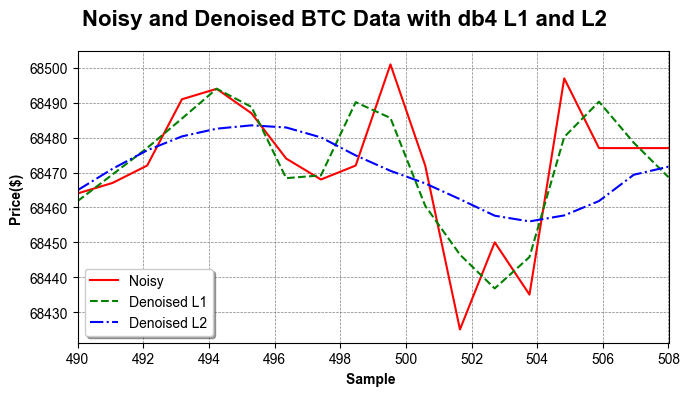

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch, Polygon


plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']


t1 = 490
t2 = 508
t = np.linspace(t1, t2, t2-t1)
signal1 = close[t1:t2]
signal2 = denoised_data_1[t1:t2]
signal3 = denoised_data_2[t1:t2]


# Create the figure and axes
fig, axs = plt.subplots(1, 1, figsize=(7, 4))

# Main plot
axs.plot(t, signal1, 'r', label=f'Noisy')
axs.plot(t, signal2, color = 'green',linestyle= '--', label = 'Denoised L1')
axs.plot(t, signal3, color = 'blue', linestyle = '-.', label=f'Denoised L2' )
axs.set_xlim(t1,t2)
axs.grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
axs.set_ylabel('Price($) ', fontsize=10, fontweight='bold')
axs.set_xlabel('Sample ', fontsize=10, fontweight='bold')
axs.legend(loc='best', fontsize=10, frameon=True, shadow=True, fancybox=True)
axs.set_facecolor('white')


axs.spines['top'].set_visible(True)
axs.spines['right'].set_visible(True)
axs.spines['bottom'].set_visible(True)
axs.spines['left'].set_visible(True)

fig.suptitle(f'Noisy and Denoised {STOCK} Data with db4 L1 and L2', fontsize=16, fontweight='bold')
# Show the plot
plt.tight_layout()
plt.savefig(f'denoise/img/noisy_denoised_{STOCK}_L1_L2.png', dpi=300, bbox_inches='tight')
plt.show()